# 1. Exploración: ¿qué decide que alguien cruce la puerta?

CRISP-DM fase 2 — *Data Understanding*.

La pregunta del negocio es cuánta gente entra a un show. Antes de modelar nada,
hay que saber **qué mueve realmente esa cifra**. Este notebook contesta seis
preguntas y cada respuesta condiciona una decisión de diseño del modelo.

1. ¿Cuántos datos hay y qué está etiquetado?
2. ¿Qué señal manda?
3. ¿En qué se diferencia agosto de julio?
4. ¿Para qué sirve cruzar con Boom?
5. ¿Qué otras señales hay?
6. ¿Cuánto varía entre shows y entre artistas?

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from ft.datos import tickets, tasa, eventos, artistas, boom_tickets
from ft.api import FIGURES, asegurar_carpetas

asegurar_carpetas()
plt.rcParams.update({
    'figure.dpi': 110, 'font.size': 10, 'axes.spines.top': False,
    'axes.spines.right': False, 'axes.grid': True, 'grid.alpha': .25,
})
AZUL, NARANJA, GRIS = '#3b6ef5', '#f5a03b', '#8b93a7'

df = tickets()
print(f'{len(df):,} entradas  ·  {df.event_id.nunique()} eventos  ·  {df.sale_id.nunique():,} ventas')

11,931 entradas  ·  62 eventos  ·  6,383 ventas


## 1. Qué hay etiquetado

Julio ya pasó: cada entrada dice si cruzó la puerta. Agosto es lo que hay que
proyectar y viene con `checked_in` vacío. Esa frontera es también la frontera
entre el set de entrenamiento y el objetivo.

In [2]:
resumen = df.groupby('month').agg(
    entradas=('ticket_id', 'size'),
    eventos=('event_id', 'nunique'),
    etiquetadas=('etiquetado', 'sum'),
    tasa_real=('y', 'mean'),
)
display(resumen)

lab = df[df.etiquetado]
print(f'Tasa global de asistencia en julio: {lab.y.mean():.1%}')
print(f'Si asumiéramos que entran todos, nos pasaríamos por '
      f'{(1 - lab.y.mean()) * len(lab):,.0f} personas solo en julio.')

,entradas,eventos,etiquetadas,tasa_real
month,,,,
agosto,5209,30,0,NaN
julio,6722,32,6722,0.739215


Tasa global de asistencia en julio: 73.9%
Si asumiéramos que entran todos, nos pasaríamos por 1,753 personas solo en julio.


## 2. La señal dominante: el tipo de entrada

Esta es la primera cosa que hay que mirar, y resultó ser la más importante de
todas.

,n,entran,tasa
tipo,,,
VIP,545,517,0.948624
Preferencial,954,896,0.939203
General,2785,2613,0.938241
Cortesía,2438,943,0.386792


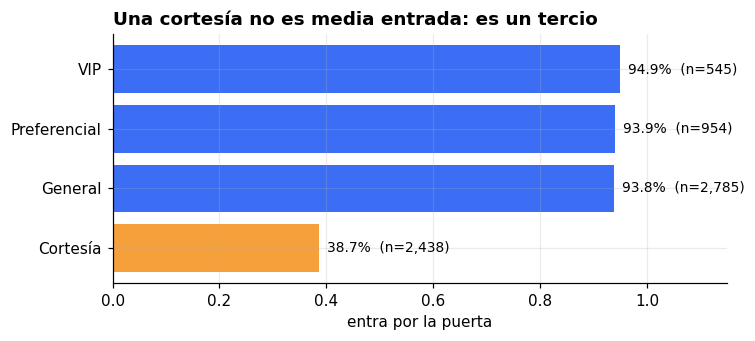

In [3]:
por_tipo = tasa(df, 'tipo')
display(por_tipo)

fig, ax = plt.subplots(figsize=(7, 3.2))
orden = por_tipo.sort_values('tasa')
colores = [NARANJA if i == 'Cortesía' else AZUL for i in orden.index]
ax.barh(orden.index, orden.tasa, color=colores)
for i, (n, t) in enumerate(zip(orden.n, orden.tasa)):
    ax.text(t + .015, i, f'{t:.1%}  (n={n:,})', va='center', fontsize=9)
ax.set_xlim(0, 1.15)
ax.set_xlabel('entra por la puerta')
ax.set_title('Una cortesía no es media entrada: es un tercio', loc='left', fontweight='bold')
fig.tight_layout()
fig.savefig(FIGURES / '01_tasa_por_tipo.png', bbox_inches='tight')
plt.show()

**Hallazgo 1.** Las tres entradas pagadas son indistinguibles entre sí (93.8% /
93.9% / 94.9%) y la cortesía está 55 puntos por debajo. Lo que separa no es el
precio exacto sino **si hubo plata de por medio**.

→ *Decisión de modelado:* el corte natural es cortesía vs pagada, no cuatro
categorías. Y sugiere entrenar **dos modelos separados** en vez de uno con una
variable más.

## 3. Agosto no se parece a julio

Si la mezcla de tipos manda, entonces comparar el total vendido entre meses no
dice nada. Hay que comparar la mezcla.

tipo,Cortesía,General,Preferencial,VIP
month,,,,
julio,36.3%,41.4%,14.2%,8.1%
agosto,47.2%,34.5%,10.2%,8.0%


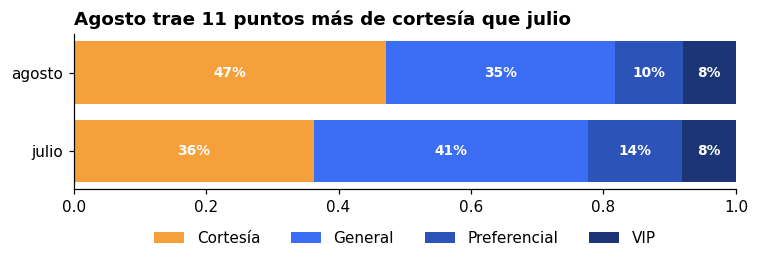

Asistencia esperada solo por la mezcla:
  julio: 73.9%
  agosto: 67.9%


In [4]:
mezcla = (pd.crosstab(df.month, df.tipo, normalize='index')
            .loc[['julio', 'agosto'], ['Cortesía', 'General', 'Preferencial', 'VIP']])
display(mezcla.style.format('{:.1%}'))

fig, ax = plt.subplots(figsize=(7, 2.6))
izq = np.zeros(2)
for col, color in zip(mezcla.columns, [NARANJA, AZUL, '#2c53b8', '#1b3577']):
    ax.barh(mezcla.index, mezcla[col], left=izq, label=col, color=color)
    for i, v in enumerate(mezcla[col]):
        if v > .04:
            ax.text(izq[i] + v / 2, i, f'{v:.0%}', ha='center', va='center',
                    color='white', fontsize=9, fontweight='bold')
    izq += mezcla[col].values
ax.set_xlim(0, 1)
ax.legend(ncol=4, loc='upper center', bbox_to_anchor=(.5, -.18), frameon=False)
ax.set_title('Agosto trae 11 puntos más de cortesía que julio', loc='left', fontweight='bold')
ax.grid(False)
fig.tight_layout()
fig.savefig(FIGURES / '02_mezcla_julio_agosto.png', bbox_inches='tight')
plt.show()

esperado = (mezcla * por_tipo.tasa).sum(axis=1)
print('Asistencia esperada solo por la mezcla:')
for mes, v in esperado.items():
    print(f'  {mes}: {v:.1%}')

**Hallazgo 2.** Agosto tiene 47.2% de cortesías contra 36.3% en julio. Solo por
ese cambio de mezcla, la asistencia esperada cae ~5 puntos **aunque no cambie
nada más**.

→ *Consecuencia:* cualquier baseline que use la tasa global de julio (74.3%) va a
sobreestimar agosto de forma sistemática. La mezcla tiene que estar en el modelo.

## 4. ¿Para qué sirve cruzar con Boom?

El cruce cuesta trabajo (es la mitad del reto). La pregunta honesta es si aporta
algo una vez que ya sabemos el tipo de entrada.

,segmento,banda_use_rate,n,tasa
0,Cortesía,bajo (<0.4),249,0.305221
1,Cortesía,medio (0.4-0.7),471,0.363057
2,Cortesía,alto (>0.7),738,0.380759
3,Pagada,bajo (<0.4),386,0.930052
4,Pagada,medio (0.4-0.7),736,0.929348
5,Pagada,alto (>0.7),1367,0.940015


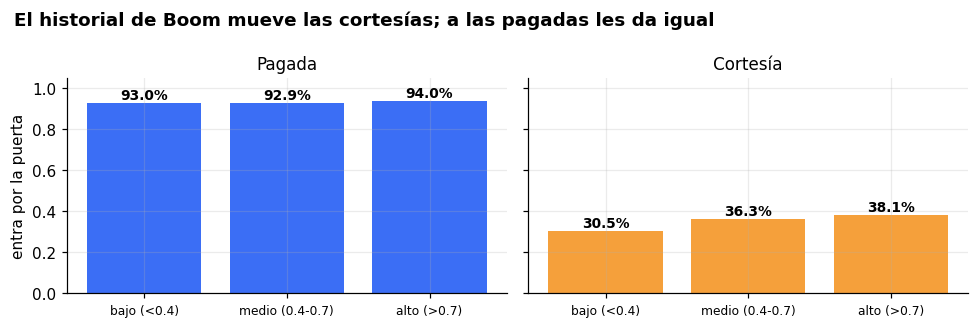

In [5]:
lab = df[df.etiquetado].copy()
lab['segmento'] = np.where(lab.es_cortesia, 'Cortesía', 'Pagada')
lab['banda_use_rate'] = pd.cut(lab.rate_consumo, [-.01, .4, .7, 1.01],
                               labels=['bajo (<0.4)', 'medio (0.4-0.7)', 'alto (>0.7)'])

tab = (lab.groupby(['segmento', 'banda_use_rate'], observed=True)['y']
          .agg(n='size', tasa='mean').reset_index())
display(tab)

fig, axes = plt.subplots(1, 2, figsize=(9, 3), sharey=True)
for ax, seg, color in zip(axes, ['Pagada', 'Cortesía'], [AZUL, NARANJA]):
    s = tab[tab.segmento == seg]
    ax.bar(range(len(s)), s.tasa, color=color)
    ax.set_xticks(range(len(s)))
    ax.set_xticklabels(s.banda_use_rate, fontsize=8)
    for i, (t, n) in enumerate(zip(s.tasa, s.n)):
        ax.text(i, t + .02, f'{t:.1%}', ha='center', fontsize=9, fontweight='bold')
    ax.set_title(seg, fontsize=11)
    ax.set_ylim(0, 1.05)
axes[0].set_ylabel('entra por la puerta')
fig.suptitle('El historial de Boom mueve las cortesías; a las pagadas les da igual',
             fontweight='bold', x=.02, ha='left')
fig.tight_layout()
fig.savefig(FIGURES / '03_boom_por_segmento.png', bbox_inches='tight')
plt.show()

**Hallazgo 3 — el que define la arquitectura del modelo.**

- En **pagadas**, el `use_rate` de Boom es plano (~93%). Ya pagó: va.
- En **cortesías**, separa 12 puntos (26.5% → 38.6%). Ahí sí importa *quién*
  recibió la entrada.

→ *Decisión:* el cruce con Boom no sirve para predecir todo; sirve para predecir
**la mitad difícil**. Dos modelos separados, y la señal de Boom solo en el de
cortesías.

Ojo con el atajo: el `use_rate` crudo del perfil mezcla los dos tipos de entrada
de Boom. Hay que separarlos.

In [6]:
bt = boom_tickets()
por_tipo_boom = bt.groupby('type')['used'].agg(n='size', tasa='mean')
display(por_tipo_boom)
print('Una entrada de membresía no pasa del 60%; la de consumo mínimo ronda el 75%.')
print('Promediarlas juntas subestima al fiel que solo usa membresía.')

,n,tasa
type,,
consumo_minimo,14266,0.749404
membresia,8059,0.464946


Una entrada de membresía no pasa del 60%; la de consumo mínimo ronda el 75%.
Promediarlas juntas subestima al fiel que solo usa membresía.


## 5. Otras señales

Canal de venta, ciudad del comprador y anticipación de la compra. Todas medidas
solo dentro de cortesías, que es donde queda varianza por explicar.

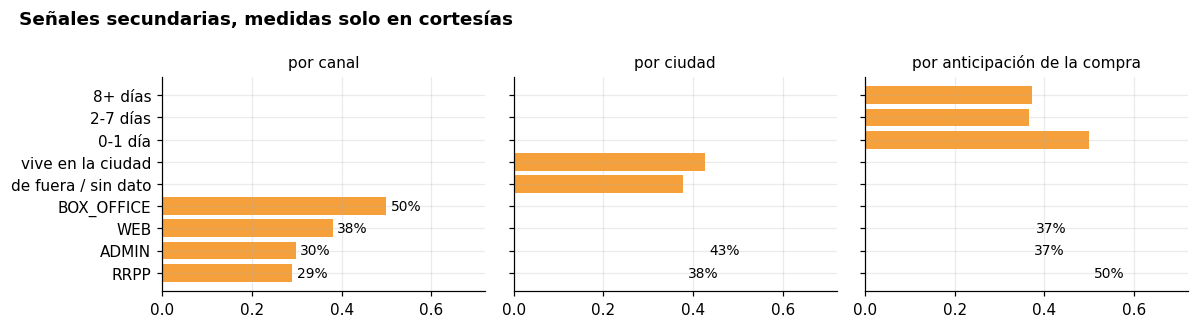

In [7]:
cort = lab[lab.es_cortesia]

fig, axes = plt.subplots(1, 3, figsize=(11, 3), sharey=True)

c = cort.groupby('canal')['y'].agg(n='size', tasa='mean').query('n >= 25').sort_values('tasa')
axes[0].barh(c.index, c.tasa, color=NARANJA)
for i, (t, n) in enumerate(zip(c.tasa, c.n)):
    axes[0].text(t + .01, i, f'{t:.0%}', va='center', fontsize=9)
axes[0].set_title('por canal', fontsize=10)

ciu = cort.groupby(cort.misma_ciudad.map({True: 'vive en la ciudad', False: 'de fuera / sin dato'}))['y'].agg(n='size', tasa='mean')
axes[1].barh(ciu.index, ciu.tasa, color=NARANJA)
for i, t in enumerate(ciu.tasa):
    axes[1].text(t + .01, i, f'{t:.0%}', va='center', fontsize=9)
axes[1].set_title('por ciudad', fontsize=10)

cort = cort.assign(banda_dias=pd.cut(cort.dias_anticipacion, [-.01, 1, 7, 1e9],
                                     labels=['0-1 día', '2-7 días', '8+ días']))
ant = cort.groupby('banda_dias', observed=True)['y'].agg(n='size', tasa='mean')
axes[2].barh(ant.index.astype(str), ant.tasa, color=NARANJA)
for i, t in enumerate(ant.tasa):
    axes[2].text(t + .01, i, f'{t:.0%}', va='center', fontsize=9)
axes[2].set_title('por anticipación de la compra', fontsize=10)

for ax in axes:
    ax.set_xlim(0, .72)
fig.suptitle('Señales secundarias, medidas solo en cortesías', fontweight='bold', x=.02, ha='left')
fig.tight_layout()
fig.savefig(FIGURES / '04_senales_secundarias.png', bbox_inches='tight')
plt.show()

**Hallazgo 4.** Las tres separan:

- **Canal**: taquilla 50% vs RRPP 29%. Quien va físicamente a recoger la cortesía
  ya demostró intención.
- **Ciudad**: vivir donde es el show suma ~9 puntos.
- **Anticipación**: la cortesía pedida el mismo día entra al 50%; la de hace tres
  semanas, al 37%.

⚠️ **Cuidado causal.** Estas son diferencias *observacionales*. Que las cortesías
de taquilla entren más probablemente refleja **a quién** se le dan, no que el
canal cause la asistencia. Sirven para predecir; para prescribir hay que
declarar el supuesto.

## 6. ¿Cuánto queda por explicar a nivel de show?

Si la mezcla de tipos explicara todo, el residuo por evento sería cero. Vamos a
medirlo: predecimos cada show de julio usando **solo** la tasa por tipo y vemos
cuánto nos falla.

MAE por evento usando solo la mezcla: 7.5 personas


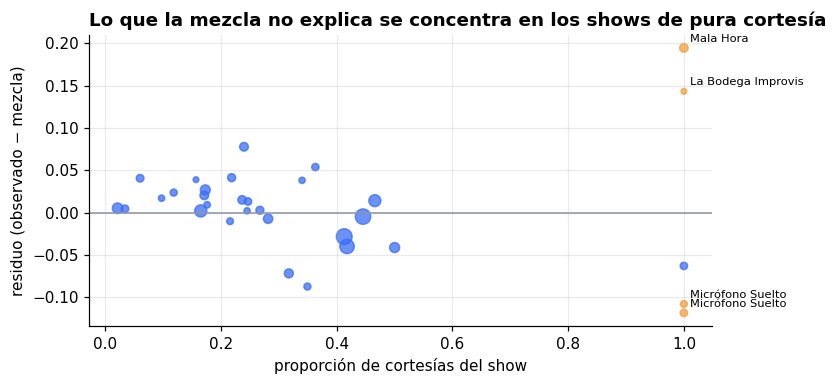

,event_id,artist_name,n,pct_cortesia,obs,pred,residuo
1,ft_evt_0002,Mala Hora,184,1.000000,107,71.169811,0.194729
17,ft_evt_0030,La Bodega Improvisa,83,1.000000,44,32.103774,0.143328
8,ft_evt_0013,Micrófono Suelto,138,1.000000,37,53.377358,-0.118677
7,ft_evt_0012,Micrófono Suelto,122,1.000000,34,47.188679,-0.108104
5,ft_evt_0010,Micrófono Suelto,126,0.349206,83,94.019990,-0.08746
11,ft_evt_0020,Doble Sentido,192,0.239583,170,155.057303,0.077827


In [8]:
base = por_tipo.tasa.to_dict()
lab_ev = df[df.etiquetado].copy()
lab_ev['p_mix'] = lab_ev.tipo.map(base)

ev = lab_ev.groupby(['event_id', 'artist_name']).agg(
    n=('ticket_id', 'size'), obs=('y', 'sum'), pred=('p_mix', 'sum'),
    pct_cortesia=('es_cortesia', 'mean')).reset_index()
ev['residuo'] = (ev.obs - ev.pred) / ev.n
print(f'MAE por evento usando solo la mezcla: {(ev.obs - ev.pred).abs().mean():.1f} personas')

fig, ax = plt.subplots(figsize=(7.5, 3.6))
sc = ax.scatter(ev.pct_cortesia, ev.residuo, s=ev.n / 6,
                c=np.where(ev.residuo.abs() > .1, NARANJA, AZUL), alpha=.75)
ax.axhline(0, color=GRIS, lw=1)
ax.set_xlabel('proporción de cortesías del show')
ax.set_ylabel('residuo (observado − mezcla)')
ax.set_title('Lo que la mezcla no explica se concentra en los shows de pura cortesía',
             loc='left', fontweight='bold')
for _, r in ev[ev.residuo.abs() > .1].iterrows():
    ax.annotate(r.artist_name[:18], (r.pct_cortesia, r.residuo),
                fontsize=7.5, xytext=(4, 4), textcoords='offset points')
fig.tight_layout()
fig.savefig(FIGURES / '05_residuo_por_evento.png', bbox_inches='tight')
plt.show()

display(ev.reindex(ev.residuo.abs().sort_values(ascending=False).index)
          [['event_id', 'artist_name', 'n', 'pct_cortesia', 'obs', 'pred', 'residuo']].head(6))

**Hallazgo 5.** La mezcla sola deja un MAE de ~7.5 personas por evento, y el
error **no está repartido al azar**: se concentra en los shows con alta
proporción de cortesías. Justo donde el brief dice que manda el *quién*.

→ *Consecuencia:* el margen de mejora del modelo está casi todo en cortesías, y
el intervalo de confianza tiene que ser más ancho en esos shows.

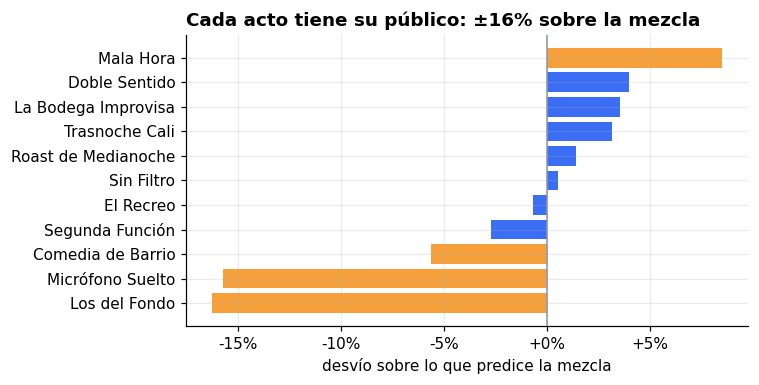

,n,factor
artist_name,,
Los del Fondo,139,0.836989
Micrófono Suelto,591,0.842544
Comedia de Barrio,529,0.943596
Segunda Función,1256,0.973043
El Recreo,604,0.993149
Sin Filtro,284,1.005563
Roast de Medianoche,625,1.014066
Trasnoche Cali,539,1.031669
La Bodega Improvisa,785,1.03558


In [9]:
art = (lab_ev.groupby('artist_name').agg(obs=('y', 'sum'), pred=('p_mix', 'sum'),
                                         n=('ticket_id', 'size')))
art['factor'] = art.obs / art.pred
art = art.sort_values('factor')

fig, ax = plt.subplots(figsize=(7, 3.6))
col = [NARANJA if f < .95 or f > 1.05 else AZUL for f in art.factor]
ax.barh(art.index, art.factor - 1, color=col)
ax.axvline(0, color=GRIS, lw=1)
ax.set_xlabel('desvío sobre lo que predice la mezcla')
ax.xaxis.set_major_formatter(lambda x, _: f'{x:+.0%}')
ax.set_title('Cada acto tiene su público: ±16% sobre la mezcla', loc='left', fontweight='bold')
fig.tight_layout()
fig.savefig(FIGURES / '06_factor_artista.png', bbox_inches='tight')
plt.show()
display(art[['n', 'factor']])

**Hallazgo 6.** El efecto de artista va de 0.84 (Micrófono Suelto) a 1.09 (Mala
Hora): hasta 16% sobre lo que predice la mezcla. Es señal real, pero algunos
actos tienen un solo show en julio.

→ *Decisión:* el efecto de artista entra **regularizado** (encogido hacia el
promedio según cuántos shows tenga). Un acto de gira sin julio propio queda sin
ajuste, y para él solo habla Boom.

## Conclusiones que se llevan al modelado

| # | Hallazgo | Decisión de diseño |
|---|---|---|
| 1 | Pagada 94% vs cortesía 38.7% | dos modelos separados |
| 2 | Agosto trae 11 pts más de cortesía | la mezcla es obligatoria; la tasa global no sirve |
| 3 | Boom separa cortesías (12 pts), no pagadas | señal de Boom solo en el modelo de cortesías |
| 4 | Canal, ciudad y anticipación separan | entran como variables, con supuesto causal declarado |
| 5 | El residuo se concentra en shows de pura cortesía | intervalos más anchos ahí |
| 6 | Efecto de artista ±16% | dummies regularizadas, no efectos libres |

**Y una restricción metodológica:** los tickets de un mismo evento comparten
artista, venue, noche y política de cortesías. **No son independientes.** El
split tiene que ser por evento, nunca aleatorio a nivel entrada, o las métricas
salen optimistas por fuga.

Sigue en [`02_calidad_del_cruce.ipynb`](02_calidad_del_cruce.ipynb).